# Probabilistic bit-agreement protocol

I had Claude refactor this most recent protocol to make it more readable, reorganize variable declarations, and implement saving to CSV.
Each run of the protocol is now a single function call. Every input is an argument and every run builds its own seeded random generator.

Structure:
1. `calibrate_threshold(...)` — threshold from the "agree" (U) case
2. `run_protocol(...)` — runs calibration + trials, returns a summary dict
3. `append_run(...)` — appends one summary row to a CSV log
4. A single-run example, then a parameter sweep + plot.

Outcomes are now automatically stored in two different CSVs depending on whether you run the single-protocol function or the "parameter sweep" function.

In [1]:
import numpy as np
import pandas as pd
import csv, os, datetime as dt
import matplotlib.pyplot as plt

In [2]:
def calibrate_threshold(U, n, q, mu1, S_start, S_end, num_calib, percentile, rng):
    """Threshold from the 'agree' case: Alice draws from the U-distribution (mean mu1).

    Returns the `percentile`-th percentile of Bob's decision statistic |E - S/n|
    over `num_calib` trials in which Alice used distribution U.
    """
    vals = np.empty(num_calib)
    for i in range(num_calib):
        S = rng.integers(S_start, S_end + 1)
        bob_sum = rng.choice(U, size=q).sum()                 # q draws from public set U (with replacement)
        alice_sum = rng.exponential(scale=mu1, size=n - q).sum()
        A = (bob_sum + S + alice_sum) / n
        vals[i] = abs((A - mu1) - S / n)
    return float(np.percentile(vals, percentile))

In [12]:
def run_protocol(n=200000, q=250, k=8, mu1=20000, mu2=50000,
                 S_start=10000, S_end=1_000_000,
                 num_trials=2000, num_calib=10000, percentile=80, seed=None):
    """Run one full experiment and return a summary dict (one notebook run = one call).

    A fresh np.random.Generator is created from `seed`, so runs are isolated and
    reproducible. Pass seed=None for a different draw each time.

    n          --> number of total samples
    q          --> bob's samples
    k          --> size of set U
    mu1        --> mean of distribution U
    mu2        --> mean of distribution V
    S_start    --> lower bound for Bob's private key
    S_end      --> upper bound for Bob's private key
    num_trials --> number of iterations the protocol is run for
    num_calib  --> number of iterations the calibration is run for
    percentile --> the percentile of the calibration set used as threshold
    seed       --> set seed for reproducibility

    """
    rng = np.random.default_rng(seed)
    U = rng.exponential(scale=mu1, size=k)                     # public set, fixed for this run - If you want the same U for every
                                                               # trial, move U to empty cell above this function and ensure you
                                                               # edit the k value.
    threshold = calibrate_threshold(U, n, q, mu1, S_start, S_end, num_calib, percentile, rng)

    successes = correct_U = total_U = correct_V = total_V = 0
    bob_tot = alice_tot = 0.0

    for _ in range(num_trials):
        bob_sum = rng.choice(U, size=q).sum()
        S = rng.integers(S_start, S_end + 1)
        bob_tx = bob_sum + S                                  # Bob -> Alice (S masks bob_sum)

        alice_choice = "U" if rng.random() < 0.5 else "V"
        if alice_choice == "U":
          alice_sum = rng.exponential(scale=mu1, size=n - q).sum()
          m = mu1
        else:
          alice_sum = np.random.randint(0, 2*mu2, dtype=int)
          m = mu2


        E = (alice_sum + bob_tx) / n - m
        guess = "U" if abs(E - S / n) <= threshold else "V"   # S cancels here by construction

        successes += (guess == alice_choice)
        if alice_choice == "U":
            total_U += 1; correct_U += (guess == "U")
        else:
            total_V += 1; correct_V += (guess == "V")
        bob_tot += bob_sum; alice_tot += alice_sum

    return {
        "success_rate":       successes / num_trials,
        "threshold":          threshold,
        "S_start":            S_start,
        "S_end":              S_end,
        "S_range":            f"{-S_start+S_end}",
        "bob_to_alice_ratio": (bob_tot) / (alice_tot),
        "q":                  q,
        "n":                  n,
        "mu1":                mu1,
        "mu2":                mu2,
        "num_trials":         num_trials,
        "acc_given_U":        correct_U / total_U if total_U else float("nan"), #accuracy when they Alice selects U
        "acc_given_V":        correct_V / total_V if total_V else float("nan"), #Accuracy when Alice selects V
        "Set U":              U,
        "Mean of U":          sum(U)/len(U),
        "seed":               seed,
    }

In [13]:
def append_run(summary, log_path="notebook_run_log.csv"):
    """Append one summary dict as a row, writing the header only if the file is new."""
    record = {"timestamp": dt.datetime.now().isoformat(timespec="seconds"), **summary}
    write_header = not os.path.isfile(log_path)
    with open(log_path, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(record.keys()))
        if write_header:
            w.writeheader()
        w.writerow(record)
    return record

## Single run
Run the protocol once and append the summary row to `notebook_run_log.csv`.

In [7]:
summary = run_protocol(S_start=1_000_000, S_end=100_000_000, mu1=20000, mu2=50000, seed=None)     # defaults: n=200000, q=250, num_trials=2000
                                   # run_protocol(n=200000, q=250, k=8, mu1=20000, mu2=50000,
                                   # S_start=10000, S_end=1_000_000,
                                   # num_trials=2000, num_calib=100000, percentile=80, seed=None):
append_run(summary)
summary

{'success_rate': 0.713,
 'threshold': 58.228311458676444,
 'S_start': 1000000,
 'S_end': 100000000,
 'S_range': '99000000',
 'bob_to_alice_ratio': np.float64(0.0007907517263349431),
 'q': 250,
 'n': 200000,
 'mu1': 20000,
 'mu2': 50000,
 'num_trials': 2000,
 'acc_given_U': 0.8044579533941236,
 'acc_given_V': 0.6238894373149062,
 'Set U': array([27253.3443623 , 13590.44336837,  5697.80160053, 37701.45685555,
        17240.3935176 , 43961.43143846,  6476.77024273, 26328.2369425 ]),
 'Mean of U': np.float64(22281.23479100434),
 'seed': None}

## Parameter sweep

For testing how one variable may change the system when all else is held equal.

In [18]:
sweep_log = "sweep_log.csv"
if os.path.exists(sweep_log):
    os.remove(sweep_log)              # reset CSV; comment out to add to same CSV


"""
The default arguments for run_protocol are:

                n          =200000,
                q          =250,
                k          =8,
                mu1        =20000,
                mu2        =50000,
                S_start    =10000,
                S_end      =1_000_000,
                num_trials =2000,
                num_calib  =100000,
                percentile =80,
                seed       =None
"""

for n in [1_000, 10_000, 15_000, 25_000, 35_000, 50_000, 70_000]:
    for q in [10, 25, 50, 100, 200]:
        summary = run_protocol(n=n, q=q, num_trials=2000, num_calib=10000, mu1 = 80_000, mu2 = 85_000, seed=0) #If you want to edit the parameters of the run
        append_run(summary, log_path=sweep_log)
        print(f"n={n:>7}  q={q:>4}  success={summary['success_rate']:.3f}  "
              f"ratio={summary['bob_to_alice_ratio']:.2e}")

df = pd.read_csv(sweep_log)
df

n=   1000  q=  10  success=0.907  ratio=1.33e-02
n=   1000  q=  25  success=0.900  ratio=3.47e-02
n=   1000  q=  50  success=0.904  ratio=7.09e-02
n=   1000  q= 100  success=0.887  ratio=1.52e-01
n=   1000  q= 200  success=0.887  ratio=3.38e-01
n=  10000  q=  10  success=0.898  ratio=1.34e-03
n=  10000  q=  25  success=0.899  ratio=3.38e-03
n=  10000  q=  50  success=0.896  ratio=6.64e-03
n=  10000  q= 100  success=0.897  ratio=1.36e-02
n=  10000  q= 200  success=0.906  ratio=2.79e-02
n=  15000  q=  10  success=0.905  ratio=9.01e-04
n=  15000  q=  25  success=0.903  ratio=2.24e-03
n=  15000  q=  50  success=0.898  ratio=4.46e-03
n=  15000  q= 100  success=0.897  ratio=8.86e-03
n=  15000  q= 200  success=0.902  ratio=1.81e-02
n=  25000  q=  10  success=0.900  ratio=5.41e-04
n=  25000  q=  25  success=0.898  ratio=1.34e-03
n=  25000  q=  50  success=0.897  ratio=2.62e-03
n=  25000  q= 100  success=0.890  ratio=5.22e-03
n=  25000  q= 200  success=0.897  ratio=1.04e-02
n=  35000  q=  10  s

,timestamp,success_rate,threshold,S_start,S_end,S_range,bob_to_alice_ratio,q,n,mu1,mu2,num_trials,acc_given_U,acc_given_V,Set U,Mean of U,seed
0,2026-07-14T13:20:33,0.9070,3228.732379,10000,1000000,990000,0.013340,10,1000,80000,85000,2000,0.813440,1.0,[ 54394.55231751 81567.76811727 1584.533007...,53307.726125,0
1,2026-07-14T13:20:33,0.9000,3280.845883,10000,1000000,990000,0.034688,25,1000,80000,85000,2000,0.797366,1.0,[ 54394.55231751 81567.76811727 1584.533007...,53307.726125,0
2,2026-07-14T13:20:33,0.9040,3676.401761,10000,1000000,990000,0.070909,50,1000,80000,85000,2000,0.805865,1.0,[ 54394.55231751 81567.76811727 1584.533007...,53307.726125,0
3,2026-07-14T13:20:34,0.8870,4732.967629,10000,1000000,990000,0.152102,100,1000,80000,85000,2000,0.768443,1.0,[ 54394.55231751 81567.76811727 1584.533007...,53307.726125,0
4,2026-07-14T13:20:34,0.8870,7268.693432,10000,1000000,990000,0.338223,200,1000,80000,85000,2000,0.771023,1.0,[ 54394.55231751 81567.76811727 1584.533007...,53307.726125,0
5,2026-07-14T13:20:35,0.8980,1023.905001,10000,1000000,990000,0.001340,10,10000,80000,85000,2000,0.795591,1.0,[ 54394.55231751 81567.76811727 1584.533007...,53307.726125,0
6,2026-07-14T13:20:36,0.8995,1026.122872,10000,1000000,990000,0.003381,25,10000,80000,85000,2000,0.796559,1.0,[ 54394.55231751 81567.76811727 1584.533007...,53307.726125,0
7,2026-07-14T13:20:37,0.8965,1042.679205,10000,1000000,990000,0.006644,50,10000,80000,85000,2000,0.794439,1.0,[ 54394.55231751 81567.76811727 1584.533007...,53307.726125,0
8,2026-07-14T13:20:38,0.8975,1078.637026,10000,1000000,990000,0.013583,100,10000,80000,85000,2000,0.793347,1.0,[ 54394.55231751 81567.76811727 1584.533007...,53307.726125,0
9,2026-07-14T13:20:39,0.9065,1233.909440,10000,1000000,990000,0.027873,200,10000,80000,85000,2000,0.808402,1.0,[ 54394.55231751 81567.76811727 1584.533007...,53307.726125,0


## Plot: success rate vs. n, one line per q

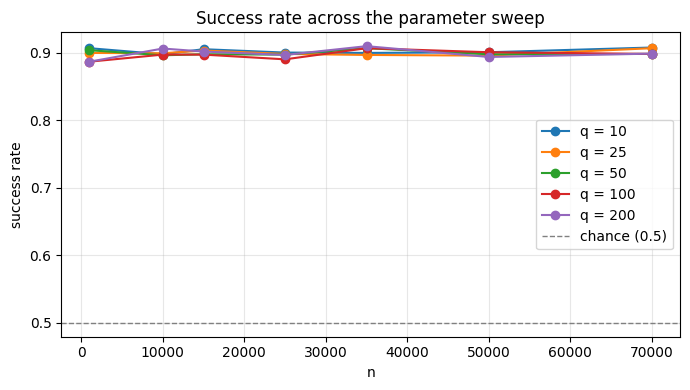

In [19]:
df = pd.read_csv(sweep_log)
fig, ax = plt.subplots(figsize=(7, 4))
for q_val, sub in df.groupby("q"):
    sub = sub.sort_values("n")
    ax.plot(sub["n"], sub["success_rate"], marker="o", label=f"q = {q_val}")
ax.axhline(0.5, ls="--", color="gray", lw=1, label="chance (0.5)")
ax.set_xlabel("n"); ax.set_ylabel("success rate")
ax.set_title("Success rate across the parameter sweep")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Setting up Eve's attack

An eavesdropper named Eve will attempt to impersonate Bob by sampling the same U that Bob does and intercepting his transmission to try and identify his private key S. There are public parameters n and q that Eve will use to do so. In order for Eve's attack to be effective here, she will likely need to know the set U that Bob has selected.

In [ ]:
#Case where Eve knows set U
attack_mu = 20_000
eve_k = 8
eve_seed = None #For reproducibility, edit to a particular value if desired
eve_q = 250
eve_S_start = 1_000_000
eve_S_end = 10_000_000
eve_num_trials = 1000

eve_rng = np.random.default_rng(eve_seed)
Eve_U = eve_rng.exponential(scale=attack_mu, size=eve_k)

In [ ]:
for l in range(eve_num_trials):
    #bob selects eve_q from U
    attack_sum = rng.choice(U, size=q).sum()
